In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [2]:

# -----------------------------
# 1. Dataset Paths
# -----------------------------
train_path = "dataset/train"
test_path = "dataset/test"



In [3]:
# -----------------------------
# 2. Data Preprocessing
# -----------------------------
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)



Found 4652 images belonging to 4 classes.
Found 2887 images belonging to 4 classes.


In [4]:
# -----------------------------
# 3. CNN Model
# -----------------------------
model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [5]:
# -----------------------------
# 4. Training
# -----------------------------
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data,
    callbacks=[early_stop]
)



Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 142s 970ms/step - accuracy: 0.6786 - loss: 0.7525 - val_accuracy: 0.9120 - val_loss: 0.2347
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 292ms/step - accuracy: 0.8977 - loss: 0.3067 - val_accuracy: 0.9262 - val_loss: 0.2092
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 292ms/step - accuracy: 0.9248 - loss: 0.2165 - val_accuracy: 0.9415 - val_loss: 0.1634
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 86s 589ms/step - accuracy: 0.9394 - loss: 0.1853 - val_accuracy: 0.9390 - val_loss: 0.1567
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 295ms/step - accuracy: 0.9428 - loss: 0.1767 - val_accuracy: 0.9522 - val_loss: 0.1537
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.9632 - loss: 0.1146 - val_accuracy: 0.9764 - val_loss: 0.0685
Epoch 7/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 28s 188ms/step - accuracy: 0.9544 - loss: 0.1387 - val_accuracy: 0.9183 - val_loss: 0.2880
Epoch 8/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step - accuracy: 0.9663 - loss: 

In [6]:
# -----------------------------
# 5. Evaluation
# -----------------------------
loss, acc = model.evaluate(test_data)
print("\nFinal Test Accuracy:", round(acc, 4))



91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9764 - loss: 0.0685

Final Test Accuracy: 0.9764


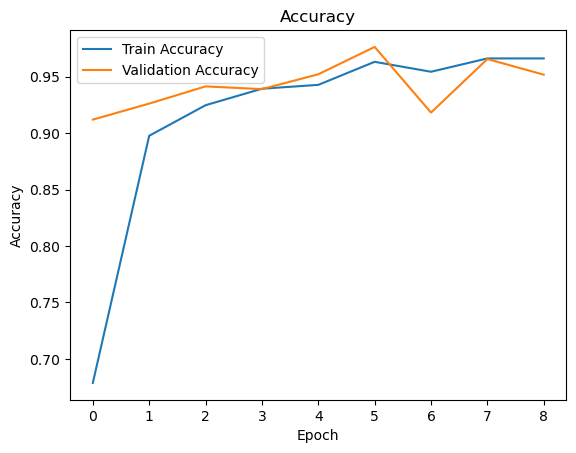

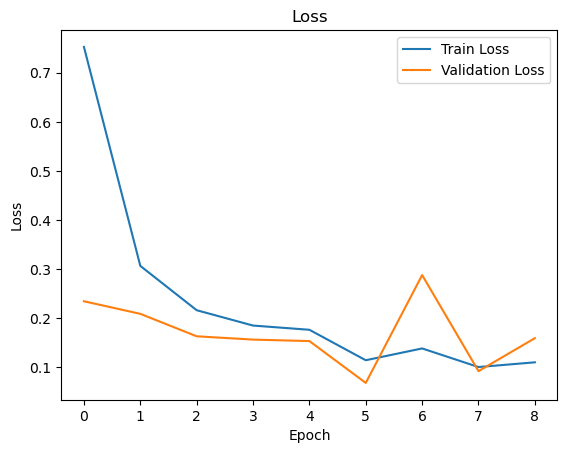

In [7]:
# -----------------------------
# 6. Plot Accuracy & Loss
# -----------------------------
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt




# =========================
# 2. DATA PATHS
# =========================
train_path = r"D:\Downloads\PlantVillage\train"
valid_path = r"D:\Downloads\PlantVillage\test"



# =========================
# 3. PREPROCESSING
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)





# =========================
# 4. CNN MODEL
# =========================
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))





# =========================
# 5. COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)





# =========================
# 6. TRAIN
# =========================
history = model.fit(
    train_data,
    epochs=5,
    validation_data=valid_data
)





# =========================
# 7. GRAPH
# =========================
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



